In [ ]:
# Jupyter notebook - calculation of STEM probe function and diameter analysis
# by J. Barthel (ju.barthel@fz-juelich.de)
#    Ernst Ruska-Centre (ER-C 2), Forschungszentrum Jülich GmbH, Jülich, Germany
#    2025 Oct 17

In [1]:
# import modules
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# define a few utility functions
def get_aperture(radius, edge_width, x, y, x0 = (0.,0.)):
    '''
    Caluclates an aperture function with given radius and edge width 
    on a 2d grid with grid coordinates as given by x and y.

    Parameters
    ----------
        radius : float
            aperture radius in units as grid coordinates x and y
        edge_width : float
            aperture adge width (smoothness) in units as grid coordinates x and y
        x, y : numpy.ndarray
            x and y coordinates on the 2d grid
        x0 : tuple, default (0.,0.)
            aperture center position (x_0, y_0)
    
    Returns
    -------
        aperture sampled on the same grid as x and y : numpy.ndarray

    '''
    return 0.5 * (1 - np.tanh((np.sqrt((x-x0[0])**2 + (y-x0[1])**2) - radius) / edge_width))
#
def get_phaseplate(aberrations, aperture, kx, ky, wavelength):
    '''
    Calculates a phase plate on a k-grid
    
    Parameters
    ----------
        aberrations : dict
            aberration coefficients with items (m, n) -> (ax, ay), where m is
             the aberration order and n the rotational symmetry, m + n is always 
             an even number and n <= m. Float numbers ax and ay are the aberration 
             coefficients in nm
        aperture : numpy.ndarray
            aperture on the k grid
        kx, ky : numpy.ndarray
            kx and ky grids (2d) in 1/nm
        wavelength : float
            electron wavelength in nm

    Returns
    -------
        phase values on a 2d k-grid : numpy.ndarray            

    '''
    ap_mask = aperture > 0.01 # mask for calculations
    act_idx = np.flatnonzero(ap_mask) # index list (relevant beams)
    kx_act = kx.flat[act_idx] # list of relevant kx values
    ky_act = ky.flat[act_idx]
    k = kx_act + 1j * ky_act # relevant k vectors in complex notation
    k_cg = kx_act - 1j * ky_act #  complex conjugate k's
    phi_act = np.zeros_like(kx_act, dtype=float) # init relevant phase values
    # run vectorized term summation on relevant beams only
    for (m, n), (ax, ay) in aberrations.items(): # loop over aberration terms requested
        a = ax + 1j * ay # complex notation of aberration coefficient
        p = (m + n) >> 1 # power of the k factor
        q = (m - n) >> 1 # power of the k_cg factor
        phi_act += wavelength**(m-1) * (a * (k**p) * (k_cg**q)).real / m # accumulate phase terms
    phi = np.zeros_like(kx, dtype=float) # initialized full phase plate
    phi.flat[act_idx] = phi_act * (2 * np.pi) # spread and normalize phase terms on full grid
    return phi
#
def get_probe(aberrations, aperture, kx, ky, wavelength, focus_spread=None, source_size=None):
    '''
    Calculates a normalized probe image
    
    Parameters
    ----------
        aberrations : dict
            aberration coefficients with items (m, n) -> (ax, ay), where m is
             the aberration order and n the rotational symmetry, m + n is always 
             an even number and n <= m. Float numbers ax and ay are the aberration 
             coefficients in nm
        aperture : numpy.ndarray
            aperture on the k grid
        kx, ky : numpy.ndarray
            kx and ky grids (2d) in 1/nm
        wavelength : float
            electron wavelength in nm
        focus_spread : None or float
            1/e half width of the focal distribution function (Gaussian) in nm, set None to omit the effect
        soure_size : None or float
            1/e half width of the effective source distribution function (Gaussian) in nm, set None to omit the effect

    Returns
    -------
        probe intensity distribution : numpy.ndarray            

    '''
    # setup coherent phase plate (see get_phaseplate)
    ap_mask = aperture > 0.01 # mask for calculations
    act_idx = np.flatnonzero(ap_mask) # index list
    kx_act = kx.flat[act_idx]
    ky_act = ky.flat[act_idx]
    k = kx_act + 1j * ky_act
    k_cg = kx_act - 1j * ky_act
    phi_act = np.zeros_like(kx_act, dtype=float)
    for (m, n), (ax, ay) in aberrations.items():
        a = ax + 1j * ay
        p = (m + n) >> 1
        q = (m - n) >> 1
        phi_act += wavelength**(m-1) * (a * (k**p) * (k_cg**q)).real / m
    phi = np.zeros_like(kx, dtype=float)
    intens_r = np.zeros_like(kx, dtype=float)
    if focus_spread is not None: # run focus-spread (chromatic aberration) kernel convolution (21 samples from -2fs to +2fs)
        phi_fs = np.zeros_like(kx_act, dtype=float)
        dfs = focus_spread / 5 # kernel defocus step 
        k2 = (k * k_cg).real # |k|^2
        for ifs in range(-10, 11): # focal loop
            df = dfs * ifs
            pf = np.exp(-df**2 / focus_spread**2) # focal weights
            phi_fs = df * wavelength *  k2 / 2 # focal phase term
            phi.flat[act_idx] = (phi_act+phi_fs) * (2 * np.pi) # effective phase plate
            wave_k = aperture * np.exp(-1J * phi) # per kernel step wave function
            intens_r += pf * np.abs(np.fft.ifft2(wave_k))**2 # incoherent probe accumulation
    else: # no chromatic aberration consideres, get coherent probe
        phi.flat[act_idx] = phi_act * (2 * np.pi)
        wave_k = aperture * np.exp(-1J * phi)
        intens_r = np.abs(np.fft.ifft2(wave_k))**2
    if source_size is not None: # spatial coherence calculation (effective / demagnified source size)
        sk = np.exp(-1 * np.pi**2 * source_size**2 * (kx**2 + ky**2)) # spatial kernel in Fourier space
        intens_r = np.fft.ifft2(np.fft.fft2(intens_r) * sk).real # convolution of the source distribution
    return intens_r / np.sum(intens_r) # probe normalization (sum = 1 (not an actual integral, a bit sloppy but sufficient here))
#
def get_d50(pdf, dx, cdf_thr=0.5, x0=(0.,0.)):
    '''
    Calculates the diameter of the smallest circle around the position x0
    that contains the fraction cdf_thr of the input pdf sampled isotropically
    with steps in dx units. The ouput diameter is in the same units as dx.
    
    Parameters
    ----------
        pdf : numpy.ndarray (2d)
            input probability distribution function (normalized to sum=1)
        dx : float
            sampling rate (pixel distance)
        cdf_thr : float, default 0.5
            threshold of circular integration, set to 0.5 for a d50 output
        x0 : tuple, default (0., 0.)
            center position of the circular area
    '''
    ndim = probe.shape
    ix = (np.fft.fftfreq(ndim[1]) * ndim[1]).astype(int) # x index list
    a_x = np.tile(ix, (ndim[1],1)) * dx; a_y = a_x.T # x and y grid
    r = 5 * dx
    r_step = 0.5 * r
    itmax = 100
    it = 0
    int_r = 0.
    while (it < itmax) and (abs(r_step) > 0.0001 * dx) and (abs(int_r - 0.5) > 0.0001):
        r_disk = get_aperture(r, dx, a_x, a_y)
        int_r = np.sum(probe * r_disk)
        if (int_r > 0.5 and r_step > 0.) or (int_r < 0.5 and r_step < 0.):
            r_step = -0.5 * r_step
        r = r + r_step
        it += 1
    return 2*r

In [3]:
# numerical grid settings
num_k = 512 # number of k-points
ikx = (np.fft.fftfreq(num_k) * num_k).astype(int) # k index list

In [10]:
# physics
e_kev = 300. # beam energy in keV (set!)
alpha = 30. # probe semi-convergence in mrad (set!)
dx = 0.002 # probe image sampling rate in nm/pixel (1/(dx*num_k)=Fourier sampling rate) (set!)
aber_coeffs = { # aberration coeffs in nm using eikonal notation with index (m,n) of equal parity and n <= m (set!)
    # comment lines out for aberrations you dont' want to include to speed up simulation
    (2,0) : (1.,0.), # defocus (C1)
    (2,2) : (0.,.1), # 2-fold astigmatism (A1)
    (3,1) : (210.,-30.), # coma (3*B2)
    (3,3) : (30.,13.), # 3-fold astigmatism (A2)
    (4,0) : (2.1E3,0.), # spherical aberration (C3)
    #(4,2) : (0.,0.), # star aberration (4*S3)
    #(4,4) : (0.,0.), # four-fold astigmatism (A3)
    #(5,1) : (0.,0.), # coma (5th order) (5*B4)
    #(5,3) : (0.,0.), # three-lobe aberration (5*D4)
    #(5,5) : (0.,0.), # five-fold astigmatism (A4)
    (6,0) : (2.E6,0.), # spherical aberration (6th order) (C5)
    #(6,2) : (0.,0.), # star aberration (6th order) (6*S5)
    #(6,4) : (0.,0.) # rosette aberration (6*R5)
    (6,6) : (1.5E6,0.) # 6-fold astigmatism (A5)
}
# ------- derived values / calculations -------
wl = 1.2398419843320025 / np.sqrt(e_kev * (e_kev + 1022.)) # wave length from e_kev
alen = dx * num_k # grid length
dk = 1. / alen # Fourier sampling rate 1./(nm*pixel)
k_max = dk * (num_k >> 1) # grid Nyquist
k_alpha = 0.001 * alpha / wl # aperture k_kmax
if (k_alpha > 0.66 * k_max):
    print(f"Warning: aperture edge ({k_alpha:.2f}/nm) is close to Nyquist ({k_max:.2f}/nm). Reduce the dx input.")
if (k_alpha/dk < 5.):
    print( "Warning: aperture contains very few beams. Increase the number of grid points or the dx input.")
akx = np.tile(ikx, (num_k,1)) * dk; aky = akx.T # kx and ky grid

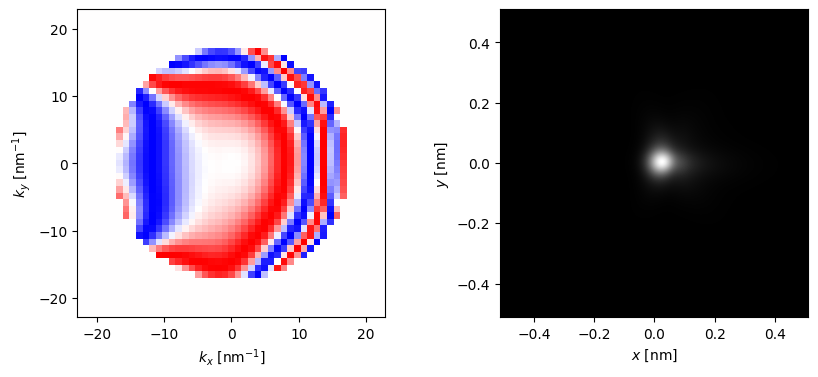

probe convergence semi-angle alpha = 30.0 mrad
probe d50 = 0.1345 nm


In [13]:
# ------- Simulation --------
aperture = get_aperture(k_alpha, dk, akx, aky) # make the aperture on the k-grid
# calculate phase plate and probe
phi = get_phaseplate(aber_coeffs, aperture, akx, aky, wl) # (cold be omitted, just for info and plotting)
probe = get_probe(aber_coeffs, aperture, akx, aky, wl, focus_spread=3., source_size=0.03)
# plotting of phase plate and probe
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].imshow(np.fft.fftshift(np.sin(phi)), vmin=-1, vmax=1, cmap='bwr', origin='lower', 
             extent=(-k_max, k_max-dk, -k_max, k_max-dk))
ax[0].set_xlabel(r'$k_x$ [nm$^{-1}$]'); ax[0].set_ylabel(r'$k_y$ [nm$^{-1}$]')
ax[0].set_xlim(-1.5 * k_alpha, 1.5*k_alpha); ax[0].set_ylim(-1.5 * k_alpha, 1.5*k_alpha)
ax[1].imshow(np.fft.fftshift(probe), vmin=0, vmax=None, cmap='gray', origin='lower',
              extent=(-alen/2, alen/2-dx, -alen/2, alen/2-dx))
ax[1].set_xlabel(r'$x$ [nm]'); ax[1].set_ylabel(r'$y$ [nm]')
plt.show()
print(f"probe convergence semi-angle alpha = {alpha:.1f} mrad")
print(f"probe d50 = {get_d50(probe, dx):.4f} nm")